<a href="https://colab.research.google.com/github/DenishShiroya22/learning_ml/blob/main/student_score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import streamlit as st

In [9]:
df = pd.read_csv("data.csv",usecols=['hours_studied','exam_score'])

<Axes: xlabel='hours_studied', ylabel='exam_score'>

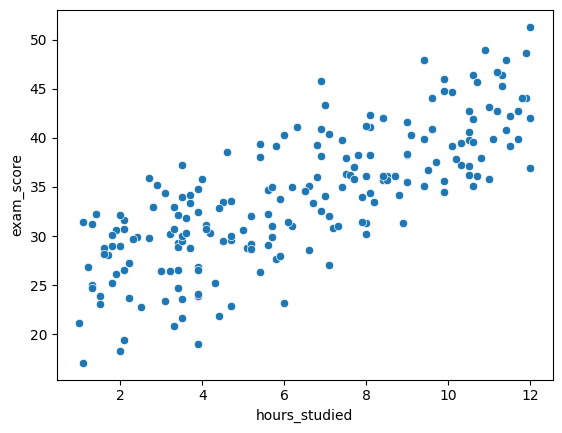

In [6]:
sns.scatterplot(data=df,x='hours_studied',y='exam_score')

In [11]:
df = df.rename(columns={
    'hours_studied':'hours',
    'exam_score':'score'
})

In [12]:
df

,hours,score
0,8.0,30.2
1,1.3,25.0
2,4.0,35.8
3,3.5,34.0
4,9.1,40.3
...,...,...
195,10.5,42.7
196,7.1,40.4
197,1.6,28.2
198,12.0,42.0


In [15]:
Q1 = df['score'].quantile(0.25)
Q3 = df['score'].quantile(0.75)
IQR = Q3 - Q1
print(IQR)

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound)
print(upper_bound)

9.25
15.625
52.625


In [16]:
clean_df = df[(df['score'] >= lower_bound) & (df['score'] <= upper_bound)]
clean_df

,hours,score
0,8.0,30.2
1,1.3,25.0
2,4.0,35.8
3,3.5,34.0
4,9.1,40.3
...,...,...
195,10.5,42.7
196,7.1,40.4
197,1.6,28.2
198,12.0,42.0


In [19]:
X = clean_df[['hours']]
y = clean_df['score']


In [20]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [21]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [24]:
coefficient = model.coef_[0]

In [25]:
print(f"For every extra hour studied, the score increases by: {coefficient:.2f} points!")

For every extra hour studied, the score increases by: 1.61 points!


In [26]:
y_predict = model.predict(X_test)


In [29]:
from sklearn.metrics import mean_absolute_error, r2_score
mae = mean_absolute_error(y_test,y_predict)
print(f"Mean Absolute Error: {mae:.2f}")
r2 = r2_score(y_test,y_predict)
print(f"R-squared: {r2:.2f}")

Mean Absolute Error: 3.83
R-squared: 0.64
